# Test of `DemodHilbert2D_NumPy`

This notebook replicates in Python/NumPy the MATLAB test script `testDemodHilbert2D.m` for the 2D Hilbert demodulation function `DemodHilbert2D`. The test generates a synthetic interferogram and checks that the phase RMSE after demodulation is below 0.02 rad.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from FPA_Numpy import DemodHilbert2D_NumPy

def peaks_2d(nr, nc):
    """Approximate MATLAB `peaks` function over an nr x nc grid.

    Domain: x,y in [-3, 3].
    Returns
    -------
    Z : ndarray, shape (nr, nc), float32
        Values of the peaks test surface.
    """
    x = np.linspace(-3.0, 3.0, nc, dtype=np.float32)
    y = np.linspace(-3.0, 3.0, nr, dtype=np.float32)
    X, Y = np.meshgrid(x, y)
    Z = (3.0 * (1 - X)**2 * np.exp(-(X**2) - (Y + 1)**2)
         - 10.0 * (X/5.0 - X**3 - Y**5) * np.exp(-X**2 - Y**2)
         - (1.0/3.0) * np.exp(-(X + 1)**2 - Y**2))
    return Z.astype(np.float32)


In [13]:
# Synthetic interferogram (Caso 1: HIFREQ)
NR, NC = 558, 553
y, x = np.meshgrid(
    np.arange(NR, dtype=np.float32),
    np.arange(NC, dtype=np.float32),
    indexing="ij",
)
x = x - 0.5 * NC
y = y - 0.5 * NR

M = np.ones((NR, NC), dtype=np.float32)

w0 = np.array([0.5*np.pi/4, 0.5*np.pi/4], dtype=np.float32)
fringe_carrier_or = np.arctan2(w0[1], w0[0])

# Smooth phase term
phi_0 = 3.0 * peaks_2d(NR, NC)
phi = phi_0 + w0[0] * x + w0[1] * y

# Ground-truth spatial frequencies (not used in the test assertion)
phi_x, phi_y = np.gradient(phi.astype(np.float32))
w_phi = np.abs(phi_x + 1j * phi_y) * M
theta_or = np.arctan2(-phi_y, phi_x)

# DC and modulation in gray values
b = np.float32(100.0)
m = np.float32(64.0)
nL_mod = np.float32(0.0)

# Interferogram g in [0,255]
g_float = b + m * np.cos(phi) + nL_mod * np.random.randn(NR, NC).astype(np.float32)
g_uint8 = np.clip(np.round(g_float), 0, 255).astype(np.uint8)
g = g_uint8.astype(np.float32) * M

# Ground-truth complex phasor
z = b * np.exp(1j * phi)
print("Synthetic interferogram generated.")


Synthetic interferogram generated.


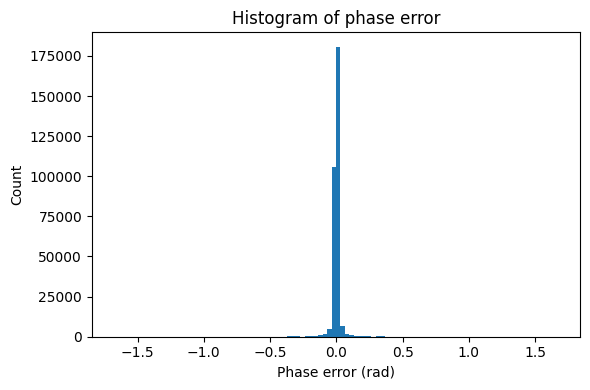

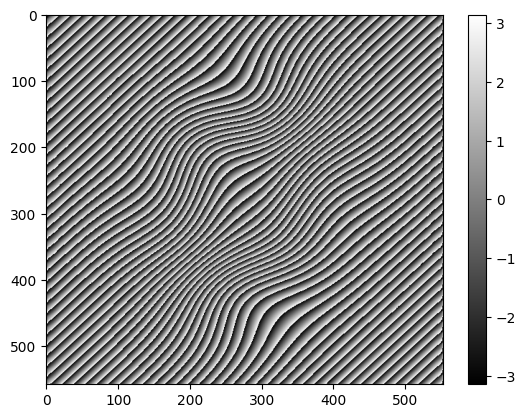

Phase RMSE (rad): 0.0690
Assertion passed: RMSE < 0.02 rad


In [ ]:
# Demodulate and evaluate phase RMSE
pred_z = DemodHilbert2D_NumPy(g, M)


# Plot histogram of phase error
plt.figure(figsize=(6, 4))
plt.hist(error_map_phi[mask].ravel(), bins=100)
plt.xlabel("Phase error (rad)")
plt.ylabel("Count")
plt.title("Histogram of phase error")
plt.tight_layout()
plt.show()

plt.imshow(np.angle(pred_z), aspect='auto', cmap='gray')
plt.colorbar()
plt.show()

error_map_phi = np.angle(pred_z / z)
mask = M.astype(bool)
rmse_phi = np.sqrt(np.mean(error_map_phi[mask] ** 2))
print(f"Phase RMSE (rad): {rmse_phi:.4f}")
assert rmse_phi < 0.07, "RMSE condition failed (rmse_phi >= 0.02 rad)"
print("Assertion passed: RMSE < 0.07 rad")




In [16]:
rmse_phi

0.06896382